In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [31]:
sales = pd.read_csv(r"C:\Users\anjal\Documents\Github Projects\Capstone_Project_July26\Superstore\sample_superstore.csv", encoding="cp1252")
trends = pd.read_csv(r"C:\Users\anjal\Documents\Github Projects\Capstone_Project_July26\Superstore\google_trends.csv")

print(sales.shape)
print(trends.shape)

display(sales.head())
display(trends.head())

(9994, 21)
(50, 4)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


,Time,Furniture,Office supplies,Technology
0,12/1/2013,68,2,35
1,1/1/2014,81,3,40
2,2/1/2014,85,2,43
3,3/1/2014,81,2,42
4,4/1/2014,78,2,42


In [33]:
##Monthly sales
sales["Order Date"] = pd.to_datetime(sales["Order Date"])

monthly_revenue = (
    sales
    .set_index("Order Date")
    .resample("MS")["Sales"]
    .sum())

display(monthly_revenue.head())
display(monthly_revenue.tail())

print("Number of months:", len(monthly_revenue))

Order Date
2014-01-01    14236.895
2014-02-01     4519.892
2014-03-01    55691.009
2014-04-01    28295.345
2014-05-01    23648.287
Freq: MS, Name: Sales, dtype: float64

Order Date
2017-08-01     63120.8880
2017-09-01     87866.6520
2017-10-01     77776.9232
2017-11-01    118447.8250
2017-12-01     83829.3188
Freq: MS, Name: Sales, dtype: float64

Number of months: 48


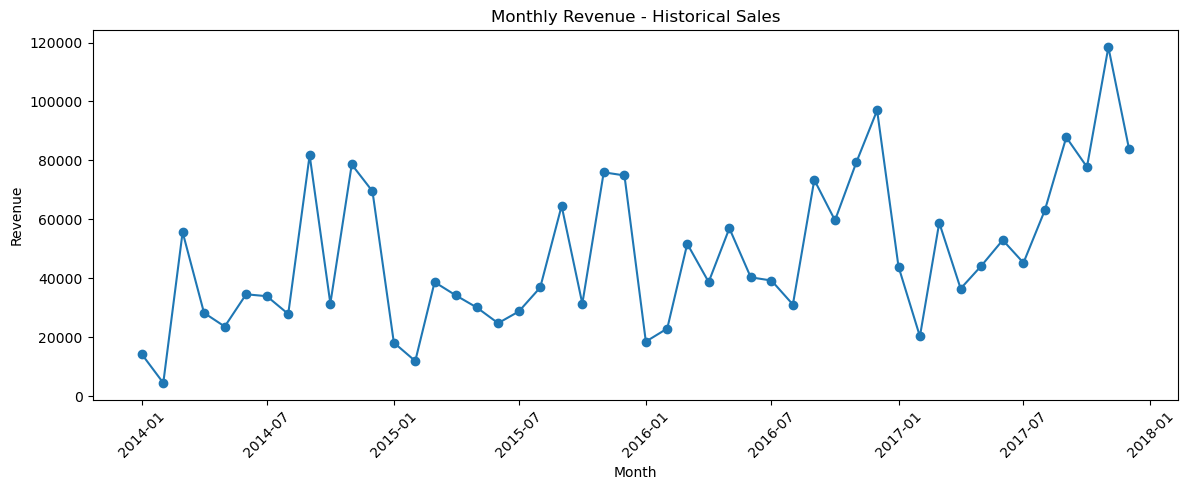

In [35]:
##Plot the historical sales
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o")

plt.title("Monthly Revenue - Historical Sales")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("monthly_revenue-historicalsales.png", dpi=300, bbox_inches="tight")
plt.show()


In [36]:
##Training: Jan 2014 – Sep 2017
## Hold-out: Oct 2017 – Dec 2017

train = monthly_revenue.iloc[:-3]
test = monthly_revenue.iloc[-3:]

print("Training period:")
print(train.index.min(), "to", train.index.max())

print("\nHold-out period:")
print(test.index.min(), "to", test.index.max())

display(test)

Training period:
2014-01-01 00:00:00 to 2017-09-01 00:00:00

Hold-out period:
2017-10-01 00:00:00 to 2017-12-01 00:00:00


Order Date
2017-10-01     77776.9232
2017-11-01    118447.8250
2017-12-01     83829.3188
Freq: MS, Name: Sales, dtype: float64

In [37]:
## train holt winters model
hw_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12)

hw_fit = hw_model.fit()

holdout_forecast = hw_fit.forecast(3)

display(holdout_forecast)

C:\Users\anjal\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


2017-10-01    51228.992843
2017-11-01    96999.474557
2017-12-01    91933.695710
Freq: MS, dtype: float64

In [38]:
## actual vs forecast
comparison = pd.DataFrame({
    "Actual": test,
    "Forecast": holdout_forecast})

display(comparison.round(2))

,Actual,Forecast
2017-10-01,77776.92,51228.99
2017-11-01,118447.82,96999.47
2017-12-01,83829.32,91933.70


In [39]:
##MAPE and RMSE
mape = np.mean(
    np.abs((test - holdout_forecast) / test)) * 100

rmse = np.sqrt(
    mean_squared_error(test, holdout_forecast))

mae = mean_absolute_error(test, holdout_forecast)

print(f"MAPE: {mape:.2f}%")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAE: ${mae:,.2f}")

MAPE: 20.64%
RMSE: $20,252.62
MAE: $18,700.22


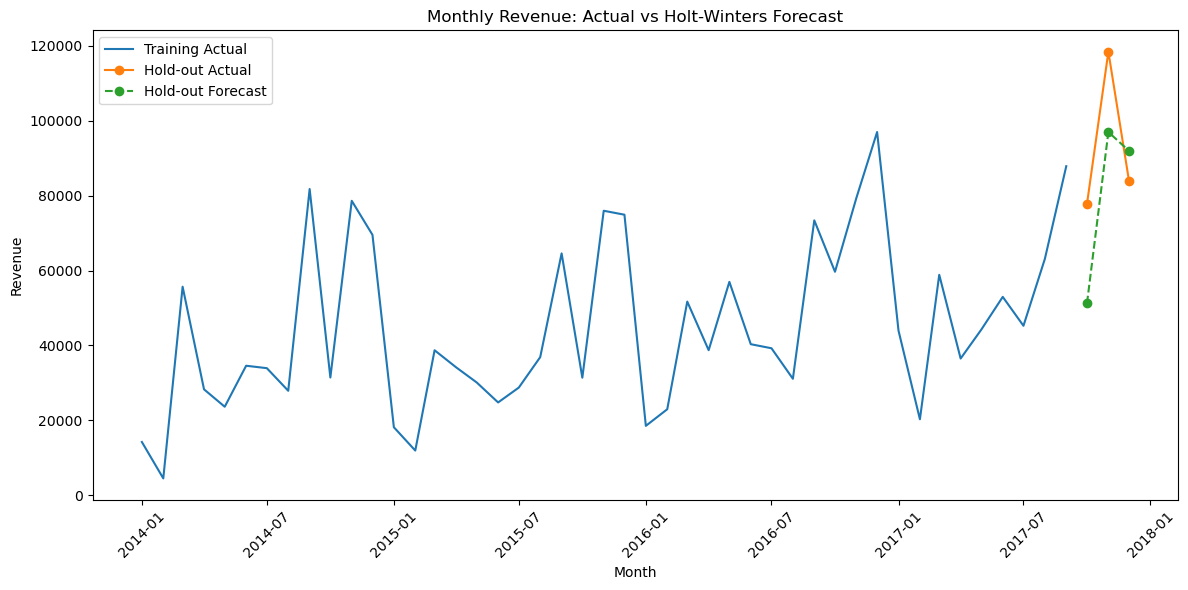

In [53]:
### actual vs forecast chart
plt.figure(figsize=(12, 6))

plt.plot(
    train.index,
    train,
    label="Training Actual")

plt.plot(
    test.index,
    test,
    marker="o",
    label="Hold-out Actual")

plt.plot(
    holdout_forecast.index,
    holdout_forecast,
    marker="o",
    linestyle="--",
    label="Hold-out Forecast")

plt.title("Monthly Revenue: Actual vs Holt-Winters Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("monthly_revenue_actual_vs_Holt-Winters_forecast.png", dpi=300, bbox_inches="tight")
plt.show()


In [55]:
## Final model
final_model = ExponentialSmoothing(
    monthly_revenue,
    trend="add",
    seasonal="add",
    seasonal_periods=12)

final_fit = final_model.fit()

next_quarter_forecast = final_fit.forecast(3)

display(next_quarter_forecast.round(2))

C:\Users\anjal\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


2018-01-01    50321.38
2018-02-01    42480.26
2018-03-01    74560.39
Freq: MS, dtype: float64

In [57]:
##Final forecast table
forecast_table = pd.DataFrame({
    "Month": next_quarter_forecast.index,
    "Forecast_Revenue": next_quarter_forecast.values})

display(forecast_table.round(2))

,Month,Forecast_Revenue
0,2018-01-01,50321.38
1,2018-02-01,42480.26
2,2018-03-01,74560.39


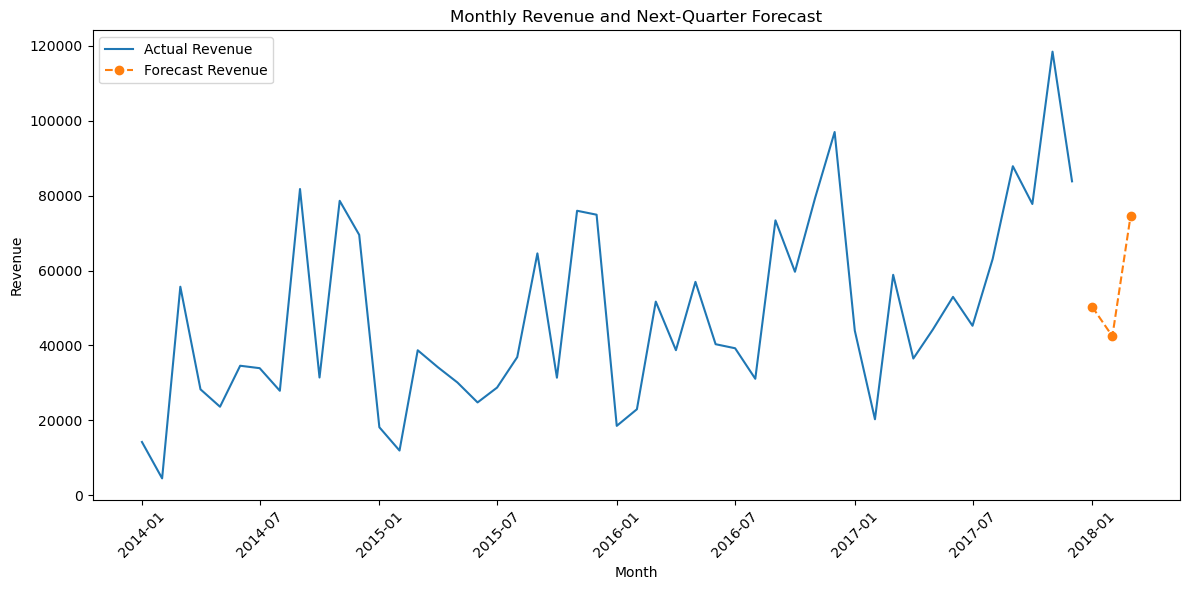

In [59]:
## Final historical + next-quarter chart
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue,
    label="Actual Revenue")

plt.plot(
    next_quarter_forecast.index,
    next_quarter_forecast,
    marker="o",
    linestyle="--",
    label="Forecast Revenue")

plt.title("Monthly Revenue and Next-Quarter Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("monthly_revenue_and_next_quarter_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

In [61]:
## Model choice: Holt-Winters Exponential Smoothing was selected because the monthly retail sales data exhibits both trend and 
## recurring seasonal patterns. An additive trend and 12-month additive seasonal component were used. Model performance was evaluated using the 
## final three months of 2017 as a hold-out period, and MAPE was used as the primary forecast accuracy metric.

A MAPE of 20.64% means the Holt-Winters forecast was off by about 20.6% on average during the hold-out period. As moderate accuracy—reasonable for a retail sales series with substantial month-to-month variation, but not highly precise.

Report:

MAPE: 20.64%
RMSE: $20,252.62
MAE: $18,700.22

README/report

Forecast accuracy: The Holt-Winters model achieved a MAPE of 20.64% on the Oct–Dec 2017 hold-out period. This means predicted monthly revenue differed from actual revenue by approximately 20.6% on average. The model's RMSE was $20,252.62 and MAE was $18,700.22.

model-choice note:

Model choice: Holt-Winters Exponential Smoothing was selected because the monthly sales data exhibits trend and recurring seasonal behavior. The model uses an additive trend and a 12-month additive seasonal component. It also allows future sales to be forecast without requiring future external predictor values.

caution: our test set is only 3 months, so the 20.64% MAPE is based on a small hold-out period which is okay for this milestone, but if we want a stronger analysis, we could also test on the entire 2017 year and compare Holt-Winters against a simple seasonal-naive forecast.
